Categorical columns: ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission']
Numerical columns: ['Year', 'Engine_Size_L', 'Price_USD']
Train size: (40000, 8)
Test size: (10000, 8)
Accuracy: 0.6947
Macro F1-score: 0.4124
Classification Report:
              precision    recall  f1-score   support

        High       0.40      0.00      0.01      3049
         Low       0.70      1.00      0.82      6951

    accuracy                           0.69     10000
   macro avg       0.55      0.50      0.41     10000
weighted avg       0.61      0.69      0.57     10000

Confusion Matrix:
[[   8 3041]
 [  12 6939]]


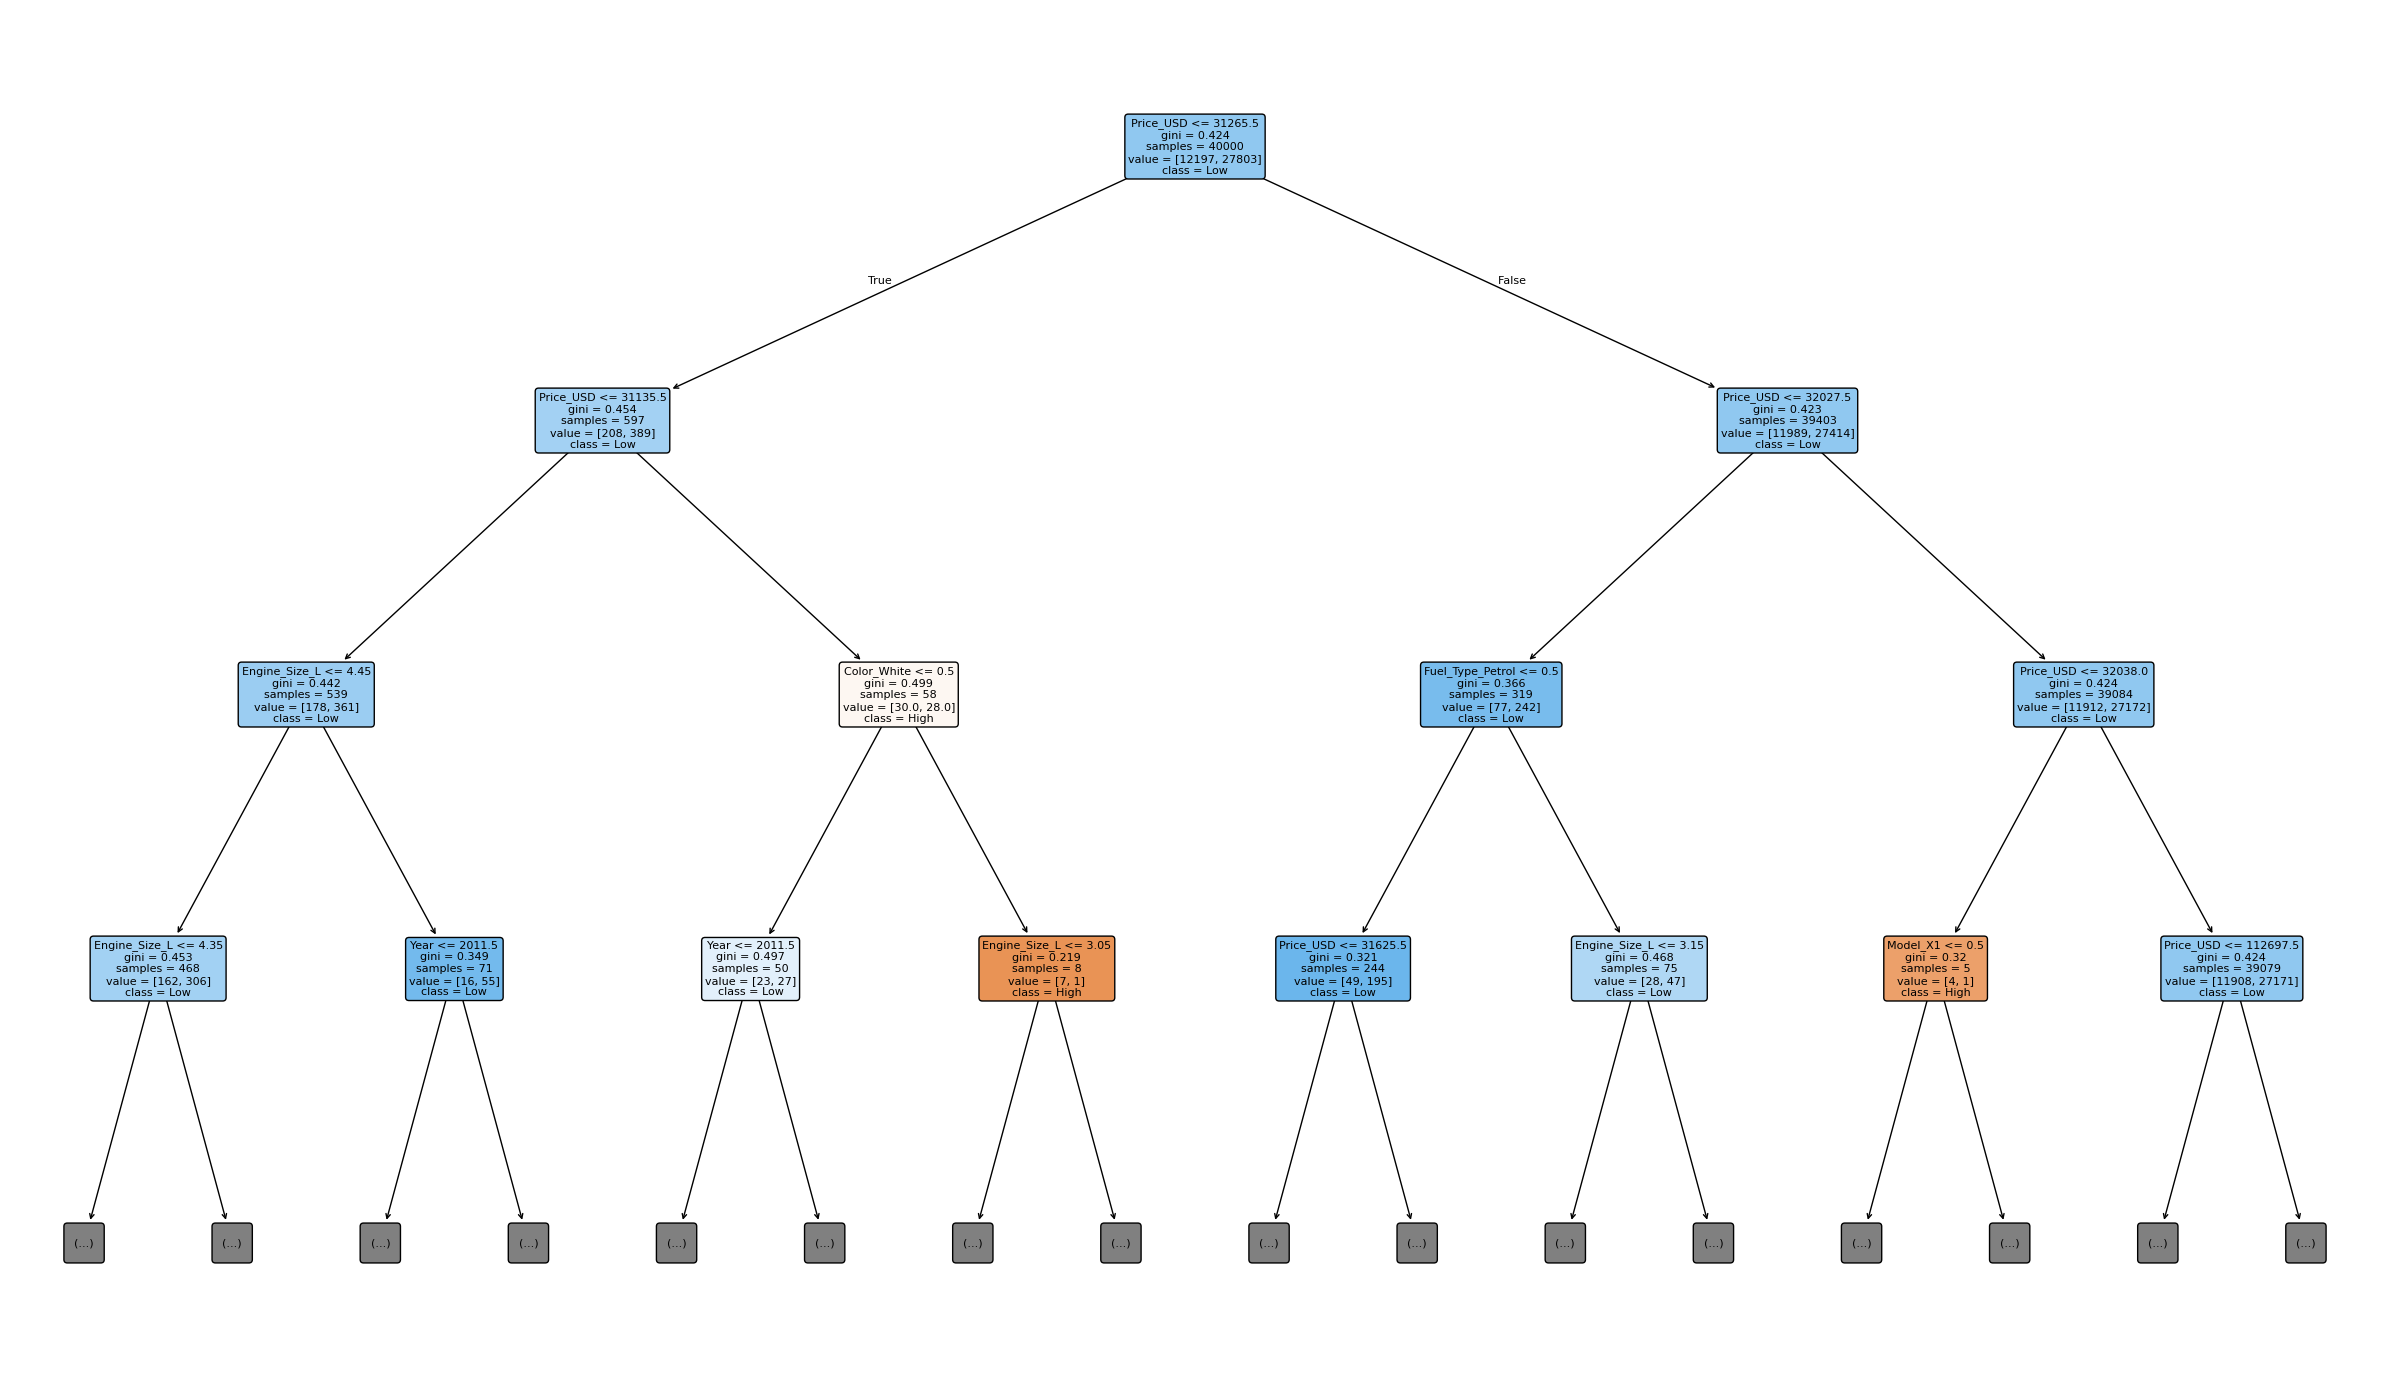

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

file_path = "/Users/diasnurmukhambetov/Desktop/group-project/BMW sales data (2010-2024) (1).csv"
df = pd.read_csv(file_path)

df.head()

target_col = "Sales_Classification"

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe columns.")

feature_cols = [c for c in df.columns if c != target_col]
df = df[feature_cols + [target_col]]


X = df.drop(columns=[target_col, "Sales_Volume", "Mileage_KM"])
y = df[target_col]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

tree_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=4,
    random_state=42
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", tree_clf),
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ohe = model.named_steps["preprocess"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(cat_cols)
all_features = list(ohe_feature_names) + num_cols

tree = model.named_steps["classifier"]

plt.figure(figsize=(24, 14))
plot_tree(
    tree,
    feature_names=all_features,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.tight_layout()
plt.show()

